# Exercício Prático — O Pipeline de Machine Learning com o dataset Iris

Neste exercício vamos percorrer, na prática, **todas as etapas do pipeline de Machine Learning** usando o dataset **Iris** (medidas de flores de 3 espécies).

**As etapas do pipeline:**

1. **Definição do problema**
2. **Preparação dos dados**
3. **Divisão treino / teste**
4. **Pré-processamento**
5. **Treinamento do modelo**
6. **Predição**
7. **Avaliação**

> 🔎 A **Visualização** aparece aqui na **exploração dos dados (EDA)**. Ela também é muito usada na *avaliação* dos resultados — isso veremos na próxima aula.  
> 🚀 Ao final, um modelo aprovado pode ser **implantado** para uso em dados novos.


## Configuração — Importar as bibliotecas

`pandas`/`numpy` para os dados, `matplotlib`/`seaborn` para os gráficos e `datasets` do scikit-learn para carregar o Iris. As funções específicas de cada etapa serão importadas na própria etapa.

In [12]:
import pandas as pd # Manipular e analisar dados em formato de tabelas (DataFrames). É excelente para limpar, filtrar e organizar dados.
import numpy as np # Realizar cálculos matemáticos e computação numérica avançada. É a base para trabalhar com matrizes e grandes arrays de números.
import seaborn as sns # Criar gráficos estatísticos bonitos, atraentes e fáceis de interpretar com poucas linhas de código.
import matplotlib.pyplot as plt # Criar gráficos básicos e customizar detalhadamente qualquer elemento visual das suas visualizações (como eixos, cores e títulos).
from sklearn import datasets # Carregar conjuntos de dados prontos (como dados de flores Iris ou preços de casas) para praticar e testar modelos de Machine Learning.

## Etapa 1 — Definição do problema

Queremos **prever a espécie de uma flor Iris** (setosa, versicolor ou virginica) a partir de 4 medidas: comprimento e largura da **sépala** e da **pétala**.

- Como a saída é uma **categoria**, esta é uma tarefa de **classificação**.
- Como os dados têm **rótulos** (sabemos a espécie de cada flor), é **aprendizado supervisionado**.

## Etapa 2 — Preparação dos dados

Carregamos o dataset, organizamos em uma tabela (**DataFrame**) e, mais adiante, separamos as **variáveis de entrada (X)** do **alvo (y)**.

In [13]:
# Carrega o dataset Iris (já vem com o scikit-learn)
data = datasets.load_iris()
# print(data.feature_names)
# print(data.data)
# print(data.target)

# Organiza os dados em uma tabela: uma coluna por medida
df = pd.DataFrame(data=data.data, columns=data.feature_names)



# Rótulo numérico da espécie (0, 1, 2)
df['target'] = data.target

# Nome da espécie (facilita a leitura e os gráficos)
df['species'] = df['target'].map({0: 'setosa', 1: 'versicolor', 2: 'virginica'})


print(df)


     sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                  5.1               3.5                1.4               0.2   
1                  4.9               3.0                1.4               0.2   
2                  4.7               3.2                1.3               0.2   
3                  4.6               3.1                1.5               0.2   
4                  5.0               3.6                1.4               0.2   
..                 ...               ...                ...               ...   
145                6.7               3.0                5.2               2.3   
146                6.3               2.5                5.0               1.9   
147                6.5               3.0                5.2               2.0   
148                6.2               3.4                5.4               2.3   
149                5.9               3.0                5.1               1.8   

     target    species  
0 

Uma olhada nas primeiras linhas e nas estatísticas descritivas:

In [14]:
# Primeiras linhas da tabela
df.head()
# Sepal length = Comprimento da sépala
# Sepal width = Largura da sépala
# Petal length = Comprimento da pétala
# Petal width = Largura da pétala

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


In [15]:
# Estatísticas descritivas de cada variável
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


### 🔎 Visualização (etapa transversal) — Exploração dos dados (EDA)

Antes de modelar, é essencial **olhar os dados**. Os **histogramas** mostram como cada variável se distribui; os **gráficos de dispersão** mostram como as espécies se separam no espaço das medidas — o que ajuda a escolher e a confiar no modelo.

array([[<Axes: title={'center': 'sepal length (cm)'}>,
        <Axes: title={'center': 'sepal width (cm)'}>],
       [<Axes: title={'center': 'petal length (cm)'}>,
        <Axes: title={'center': 'petal width (cm)'}>]], dtype=object)

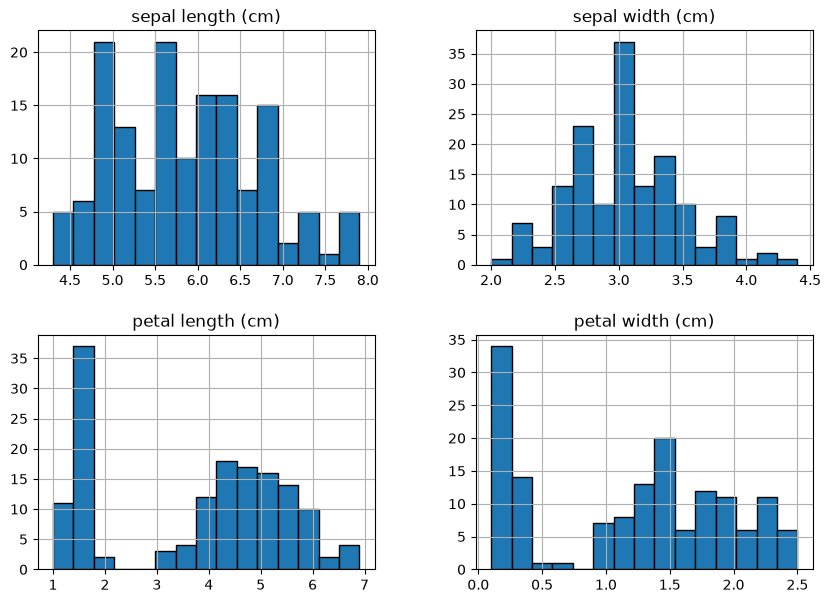

In [16]:
# Distribuição de cada medida
df[data.feature_names]
df[data.feature_names].hist(figsize=(10, 7), bins=15, edgecolor='black')
# plt.suptitle('Distribuição das variáveis', fontsize=14)
# plt.tight_layout()
# plt.show()

In [17]:
# Relação entre as variáveis, colorindo por espécie
# sns.pairplot(df, vars=data.feature_names, hue='species', markers=['o', 's', 'D'])
# plt.suptitle('Dispersão por espécie', y=1.02)
# plt.show()

### Separar as variáveis: entradas (X) e alvo (y)

`X` contém as 4 medidas (features) e `y` contém a espécie a prever (0, 1, 2).

In [18]:
X = df[data.feature_names]   # variáveis de entrada (features)
y = df['target']             # alvo a prever (rótulo)

print('X:', X.shape, '| y:', y.shape)

X: (150, 4) | y: (150,)


## Etapa 3 — Divisão em treino e teste

Separamos parte dos dados para **avaliar o modelo em exemplos que ele não viu**.

- `test_size=0.2` → 20% para teste, 80% para treino.
- `random_state=42` → fixa a aleatoriedade (qualquer número serve); garante a **mesma divisão** toda vez.
- `stratify=y` → mantém a **proporção das 3 espécies** no treino e no teste.

In [30]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)


print('Treino:', X_train.shape[0], 'amostras | Teste:', X_test.shape[0], 'amostras')

Treino: 120 amostras | Teste: 30 amostras


## Etapa 4 — Pré-processamento (padronização)

Colocamos as variáveis na **mesma escala** (média 0, desvio 1). Ajustamos o `StandardScaler` **só no treino** (`fit_transform`) e aplicamos a mesma escala no teste (`transform`), para não "vazar" informação do teste. Isso é importante para o KNN, que usa **distâncias**.

In [20]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)   # aprende a escala no treino e aplica
X_test = scaler.transform(X_test)         # aplica a MESMA escala no teste

## Etapa 5 — Treinamento do modelo (k-Nearest Neighbors)

O **KNN** classifica um ponto novo pela **maioria** entre seus `k` vizinhos mais próximos. Aqui `k = 3`. O método `.fit()` "treina" o modelo — no caso do KNN, ele apenas **memoriza** os dados de treino.

In [21]:
from sklearn.neighbors import KNeighborsClassifier 
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)

# from sklearn.tree import DecisionTreeClassifier , plot_tree
# modelo = DecisionTreeClassifier(random_state=42)
# modelo.fit(X_train, y_train)

# plot_tree(
#     modelo,
#     feature_names=data.feature_names,
#     class_names=data.feature_names,
#     filled=True,
# )



,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",3
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[int64](3,)","[0,1,2]"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


## Etapa 6 — Predição

Com o modelo treinado, geramos as previsões para o conjunto de teste com `.predict()` e comparamos com os rótulos reais.

In [22]:
y_pred = knn.predict(X_test)
# y_pred = modelo.predict(X_test)

# Compara, lado a lado, o valor real e o previsto
comparacao = pd.DataFrame({'real': y_test.values, 'previsto': y_pred})
comparacao.head(10)

,real,previsto
0,0,0
1,2,2
2,1,1
3,1,1
4,0,0
5,1,1
6,0,0
7,0,0
8,2,2
9,1,1


## Etapa 7 — Avaliação

Comparamos as previsões com os rótulos reais. A métrica mais simples é a **acurácia**: a fração de exemplos classificados corretamente (acertos / total).

In [23]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print('Acurácia do modelo KNN:', round(accuracy, 3))

Acurácia do modelo KNN: 0.933


> **A acurácia não conta a história toda.** Ela resume tudo num único número, mas não mostra *em quais espécies* o modelo erra nem se confunde uma classe com outra. Métricas mais detalhadas (**precisão**, **recall**, **F1**) e a **matriz de confusão** ficam para a **próxima aula**.

## 🚀 Próximos passos — Implantação (usar o modelo)

Um modelo aprovado pode ser **usado em dados novos**. Basta aplicar a **mesma padronização** do treino e chamar `.predict()` para uma flor nova.

In [24]:
# Medidas de uma flor nova (cm):
# [comp. sépala, larg. sépala, comp. pétala, larg. pétala]
nova_flor = pd.DataFrame([[5.1, 3.5, 1.4, 0.2]], columns=data.feature_names)

nova_flor_padronizada = scaler.transform(nova_flor)   # MESMA escala do treino
predicao = knn.predict(nova_flor_padronizada)

print('Espécie prevista:', data.target_names[predicao][0])

Espécie prevista: setosa
